# SIOC 251 – Homework 0
## Prism Dispersion and the Dark Side of the Moon

**Author:** Sophie Wynn  
**Course:** SIOC 251 – Radiative Transfer  
**Date:** April 2nd 2026

## Imports

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import os

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

## 1. Refractive Index Model

The refractive index of the prism material varies with wavelength:

$$n(\lambda) = 1.50 + \frac{0.004}{\lambda^2}$$

where $\lambda$ is in microns.

In [102]:
def refractive_index(lam):
    """Compute refractive index for wavelength lam (in microns)."""
    return 1.50 + 0.004 / lam**2

# Wavelengths and colors to simulate
wavelengths = {
    'Violet': (0.40, '#8B00FF'),
    'Blue':   (0.45, '#0000FF'),
    'Cyan':   (0.50, '#00BFFF'),
    'Green':  (0.55, '#00CC00'),
    'Yellow': (0.58, '#FFD700'),
    'Orange': (0.62, '#FF8C00'),
    'Red':    (0.70, '#FF0000'),
}

print(f"{'Color':<10} {'λ (µm)':<10} {'n(λ)':<10}")
print("-" * 30)
for color, (lam, _) in wavelengths.items():
    print(f"{color:<10} {lam:<10.2f} {refractive_index(lam):<10.5f}")

Color      λ (µm)     n(λ)      
------------------------------
Violet     0.40       1.52500   
Blue       0.45       1.51975   
Cyan       0.50       1.51600   
Green      0.55       1.51322   
Yellow     0.58       1.51189   
Orange     0.62       1.51041   
Red        0.70       1.50816   


## 2. Ray-Tracing Model

We trace rays through an equilateral triangle prism using Snell's law:

$$n_1 \sin(\theta_1) = n_2 \sin(\theta_2)$$

The prism is an equilateral triangle (apex angle = 60°). Light enters horizontally from the left.

In [103]:
def snell(theta_i, n1, n2):
    """Apply Snell's law. Returns refracted angle (radians), or None for TIR."""
    sin_t = n1 * np.sin(theta_i) / n2
    if abs(sin_t) > 1.0:
        return None  # Total internal reflection
    return np.arcsin(sin_t)


def trace_ray_through_prism(lam, apex_angle_deg=60.0, incident_angle_deg=60.0):
    """
    Trace a ray of wavelength lam (microns) through an equilateral prism.
    
    Parameters
    ----------
    lam : float
        Wavelength in microns.
    apex_angle_deg : float
        Apex angle of prism in degrees (default 60 for equilateral).
    incident_angle_deg : float
        Angle of incidence on the first prism face (degrees from normal).
    
    Returns
    -------
    deviation : float
        Total deviation angle of the ray in degrees.
    theta_exit : float
        Exit angle from prism normal at second face (degrees).
    """
    n = refractive_index(lam)
    n_air = 1.0
    A = np.radians(apex_angle_deg)
    theta1 = np.radians(incident_angle_deg)
    
    # Refraction at first surface (air -> glass)
    theta2 = snell(theta1, n_air, n)
    if theta2 is None:
        return None, None
    
    # Angle of incidence at second surface
    theta3 = A - theta2
    
    # Refraction at second surface (glass -> air)
    theta4 = snell(theta3, n, n_air)
    if theta4 is None:
        return None, None
    
    # Total deviation
    deviation = (theta1 - theta2) + (theta4 - theta3)
    
    return np.degrees(deviation), np.degrees(theta4)


print(f"{'Color':<10} {'λ (µm)':<10} {'n(λ)':<10} {'Deviation (°)':<15} {'Exit angle (°)':<15}")
print("-" * 60)
for color, (lam, _) in wavelengths.items():
    dev, exit_ang = trace_ray_through_prism(lam)
    print(f"{color:<10} {lam:<10.2f} {refractive_index(lam):<10.5f} {dev:<15.4f} {exit_ang:<15.4f}")

Color      λ (µm)     n(λ)       Deviation (°)   Exit angle (°) 
------------------------------------------------------------
Violet     0.40       1.52500    40.8481         40.8481        
Blue       0.45       1.51975    40.4309         40.4309        
Cyan       0.50       1.51600    40.1337         40.1337        
Green      0.55       1.51322    39.9144         39.9144        
Yellow     0.58       1.51189    39.8093         39.8093        
Orange     0.62       1.51041    39.6924         39.6924        
Red        0.70       1.50816    39.5160         39.5160        


## 3. Ray Path Visualization

✓ Plotted 7 rays at incident_angle=60.0°


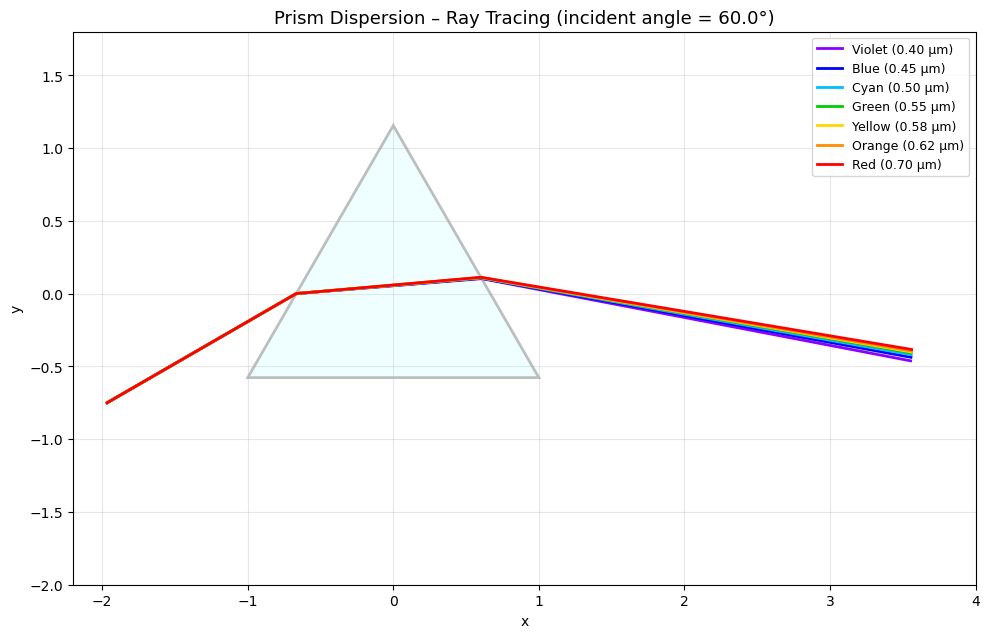

Figure saved to figures/prism_dispersion.png


In [104]:
def get_prism_geometry(apex_angle_deg=60.0, base=2.0):
    """Return vertices of an equilateral prism (2D triangle) centered near the origin."""
    h = base * np.sqrt(3) / 2
    vertices = np.array([
        [0.0,      2*h/3],
        [-base/2, -h/3],
        [ base/2, -h/3],
    ])
    return vertices


def vector_snell(d_in, n_hat_toward_incident, n1, n2):
    """
    Vector form of Snell's law.
    n_hat_toward_incident: unit normal pointing TOWARD the incident medium.
    Returns refracted unit direction, or None for TIR.
    """
    c1 = -np.dot(d_in, n_hat_toward_incident)
    if c1 < 0:
        n_hat_toward_incident = -n_hat_toward_incident
        c1 = -c1
    sin_t_sq = (n1 / n2)**2 * (1 - c1**2)
    if sin_t_sq > 1.0:
        return None   # total internal reflection
    c2 = np.sqrt(1 - sin_t_sq)
    d_t = (n1/n2) * d_in + (n1/n2 * c1 - c2) * n_hat_toward_incident
    return d_t / np.linalg.norm(d_t)


def compute_ray_path(lam, entry_y=0.0, incident_angle_deg=45.0, prism_base=2.0):
    """
    Compute the geometric path of a ray through the prism.

    incident_angle_deg: angle at the left face measured from the face normal.
        - 30° → horizontal incoming ray (minimum to avoid TIR)
        - 45° → good default, clear color spread
        - >80° → ray misses the right face
        NOTE: angles below ~30° cause total internal reflection → returns None
    """
    n = refractive_index(lam)
    n_air = 1.0

    h = prism_base * np.sqrt(3) / 2
    entry_x = -prism_base/2 + (entry_y - (-h/3)) / np.tan(np.radians(60))
    entry_pt = np.array([entry_x, entry_y])

    # Left face outward normal (upper-left, toward incident air)
    lf_normal = np.array([-np.sqrt(3), 1.0]) / 2.0

    # Incoming ray direction rotated to match incident_angle_deg
    inward_angle = np.degrees(np.arctan2(-lf_normal[1], -lf_normal[0]))
    d_in = np.array([np.cos(np.radians(inward_angle + incident_angle_deg)),
                     np.sin(np.radians(inward_angle + incident_angle_deg))])

    # Refract at entry face: air → glass
    d_refracted = vector_snell(d_in, lf_normal, n_air, n)
    if d_refracted is None:
        return None

    # Find intersection with right face
    p_br   = np.array([ prism_base/2, -h/3])
    p_apex = np.array([0.0,            2*h/3])
    A_mat = np.column_stack([d_refracted, -(p_apex - p_br)])
    b_vec = p_br - entry_pt
    try:
        t, s = np.linalg.solve(A_mat, b_vec)
    except np.linalg.LinAlgError:
        return None
    if t < 0 or not (0.0 <= s <= 1.0):
        return None
    exit_pt = entry_pt + t * d_refracted

    # Refract at exit face: glass → air
    rf_normal = np.array([np.sqrt(3), 1.0]) / 2.0
    d_exit = vector_snell(d_refracted, -rf_normal, n, n_air)
    if d_exit is None:
        return None

    exit_end    = exit_pt  + 3.0 * d_exit
    entry_start = entry_pt - 1.5 * d_in
    return [entry_start, entry_pt, exit_pt, exit_end]


# ── Plot ──────────────────────────────────────────────────────────────
# VALID RANGE: ~30° to ~80°
# Below 30° → total internal reflection (nothing exits the prism)
# Above 80° → ray exits the plot area
incident_angle = 60.0   # ← change this to explore (try 35, 45, 55, 65)

fig, ax = plt.subplots(figsize=(10, 8))
prism_base = 2.0
prism_patch = Polygon(get_prism_geometry(base=prism_base), closed=True,
                      facecolor='lightcyan', edgecolor='gray', alpha=0.5, linewidth=2)
ax.add_patch(prism_patch)

plotted = 0
for color, (lam, hex_color) in wavelengths.items():
    path = compute_ray_path(lam, entry_y=0.0, incident_angle_deg=incident_angle)
    if path is not None:
        xs = [p[0] for p in path]
        ys = [p[1] for p in path]
        ax.plot(xs, ys, color=hex_color, linewidth=2, label=f"{color} ({lam:.2f} µm)")
        plotted += 1

if plotted == 0:
    print(f"⚠️  No rays plotted at incident_angle={incident_angle}°")
    print("   Try an angle between 30° and 80°.")
else:
    print(f"✓ Plotted {plotted} rays at incident_angle={incident_angle}°")

ax.set_xlim(-2.2, 4.0)
ax.set_ylim(-2.0, 1.8)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)
ax.set_title(f'Prism Dispersion – Ray Tracing (incident angle = {incident_angle}°)', fontsize=13)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/prism_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to figures/prism_dispersion.png")

## 4. Analysis

### Based on the wavelength dependence of n(λ)
- The table in section 2 shows that the red light bends less than the purple light etc. This is because light with larger wavelengths bend more given n(λ). The amount of bend and the order of the colors lines up in the table and the image on the album, so yes this is consistent. 
### Based on the ray-tracing figure
- The figure I created looks pretty simliar to pink floyd's cover, but it takes more distance for the colors to seperate given my calculation. To get this exagerated seperation of colors that pink floyd has on the album cover has I would have to change the refractive index function depend more on lamba ie change the 0.004 to 0.04, or I could change the np.squareroot(λ) to a larger root. 

## Model Verification

I know that if the light hits the prisim normally ie at a 90 degree angle from the surface there should be no refraction of light. To do this the indicent theta would be 180 or 0 degrees since the angle is measured from the normal line of the surface. 
Using the snell's law function from eariler I set theta1 to be 180 I get theta 2 is 0, which works since they are the same angle. I also tested this for theta = 0 and got 0 out as well. See test below. 

In [ ]:
# verification: I know that light will not change direction if it strikes the prism's surface at a perfect 90-degree angle
theta_1 = np.radians(180.0) # ie normal incidence → 90° from face
n_air = 1.0
n = refractive_index(0.40)  # example wavelength
theta2 = snell(theta_1, n_air, n)
print(f"Verification: θ1 = 180, n_air = {n_air}, n = {n:.5f} → θ2 = {np.degrees(theta2):.2f}°")
theta_1 = np.radians(0.0)  # ie normal incidence → 90° from face
n_air = 1.0
n = refractive_index(0.40)  # example wavelength
theta2 = snell(theta_1, n_air, n)
print(f"Verification: θ1 = 0, n_air = {n_air}, n = {n:.5f} → θ2 = {np.degrees(theta2):.2f}°")
# read

Verification: θ1 = 180, n_air = 1.0, n = 1.52500 → θ2 = 0.00°
Verification: θ1 = 0, n_air = 1.0, n = 1.52500 → θ2 = 0.00°


## AI Usage

I used Claude to write all code, expect the model verifiation since I already had an idea of what I wanted to do myself. Claude worked will but for section three, I had to guide the model during the debugging proccess since the image was not comming out physically consistent at first. 

Claude is great because you can attach documents with your questions so I gave Claude the assignment and I asked it to make the prisim model for me, and it even left the analysis cell blank for me to do and then I just deleted the verfication cell it made since I wanted to do that on my own. After claude wrote the code I had to go back to the problem and draw the prism out myself using snells law to make sure I understood what was happening. 